# CIND820 Milestone 3 — Notebook 02: Preprocessing & Train-Test Split
**Student:** Mubarak Ahmed (501345730)
**Pipeline Stages:** Stage 2 (Target Engineering & Cleaning) and Stage 3 (Stratified Split)

**Purpose:** Execute the cleaning and splitting design specified in Milestone 2:
1. Parse date fields and derive the 3-class delay target
2. Audit and resolve cross-referenced weight/freight entries (record linkage)
3. Remove leakage fields and identifiers, with a documented exclusion log
4. Perform a stratified 80/20 train-test split (`random_state=42`) and save all artifacts

**Leakage prevention note:** every operation in this notebook is either deterministic row-level cleaning (no statistics estimated from data) or the split itself. All *statistical* transformations (imputation, encoding, scaling, SMOTE) are deferred to Notebook 03/04 and fitted on training data only.

In [1]:
# Section 1: Imports — preprocessing logic lives in the modular src/ package
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import preprocessing as prep

print("Modules loaded. Random state:", prep.RANDOM_STATE)

Modules loaded. Random state: 42


## Section 2: Load raw data and derive the target variable

In [2]:
# Load raw CSV (latin1 encoding per Milestone 2 audit) and parse dates
df = prep.load_raw_data('../data/raw/Suppy_Chain_Shipment_Data.csv')
df = prep.parse_dates(df)
df = prep.engineer_target(df)

print(f"Dataset shape: {df.shape}")
print("\nDelay class distribution (full dataset):")
counts = df['delay_class'].value_counts().sort_index()
pcts = (df['delay_class'].value_counts(normalize=True).sort_index() * 100).round(1)
for cls, name in [(0, 'On-time'), (1, 'At-risk'), (2, 'Delayed')]:
    print(f"  Class {cls} ({name}): {counts[cls]:,} ({pcts[cls]}%)")
print(f"\nRecords with unparseable dates (class = -1): {(df['delay_class'] == -1).sum()}")
print(f"delay_days range: {df['delay_days'].min():.0f} to {df['delay_days'].max():.0f} days")

Dataset shape: (10324, 35)

Delay class distribution (full dataset):
  Class 0 (On-time): 9,138 (88.5%)
  Class 1 (At-risk): 691 (6.7%)
  Class 2 (Delayed): 495 (4.8%)

Records with unparseable dates (class = -1): 0
delay_days range: -372 to 192 days


## Section 3: Cross-reference recovery for weight and freight cost

The Milestone 2 audit reported headline NaN rates of ~4% for weight and freight cost.
Implementation-stage auditing revealed the true picture: these columns are stored as **text**,
and ~38–40% of entries are placeholders such as `Weight Captured Separately`,
`Freight Included in Commodity Cost`, or cross-references like `See DN-304 (ID#:10589)`.

The cross-references are resolvable: they point to another row's `id` whose record carries the
actual value. Resolving them is deterministic record linkage — it uses only row identifiers,
never the target — so it is leakage-safe and is performed **before** the train-test split.

In [ ]:
# Resolve 'See ASN-93 (ID#:1281)' cross-references (one hop) and log recovery
df, recovery_log = prep.resolve_cross_references(df)
recovery_log

,column,directly_numeric,cross_references_found,recovered_via_lookup,usable_after_recovery,usable_pct_after_recovery
0,weight (kilograms),6372,2445,2319,8691,84.2
1,freight cost (usd),6198,2445,2340,8538,82.7


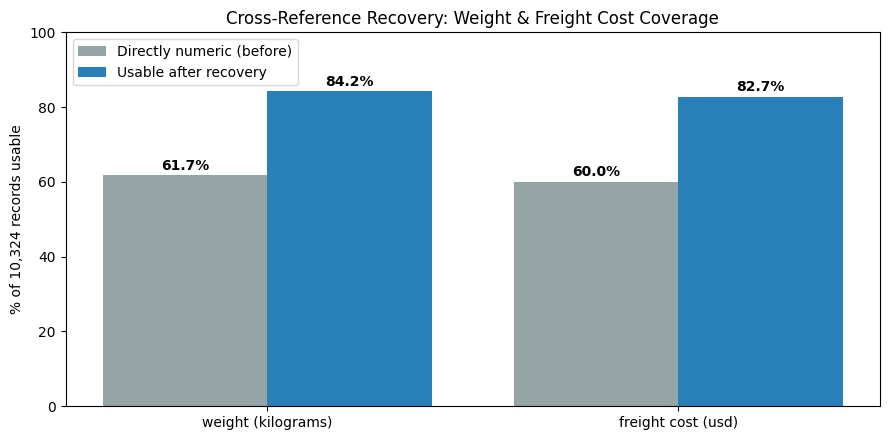

Figure saved to outputs/figures/cross_reference_recovery.png


In [4]:
# Visualize the recovery impact
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(recovery_log))
before = recovery_log['directly_numeric'] / len(df) * 100
after = recovery_log['usable_pct_after_recovery']
ax.bar(x - 0.2, before, 0.4, label='Directly numeric (before)', color='#95a5a6')
ax.bar(x + 0.2, after, 0.4, label='Usable after recovery', color='#2980b9')
ax.set_xticks(x); ax.set_xticklabels(recovery_log['column'])
ax.set_ylabel('% of 10,324 records usable')
ax.set_title('Cross-Reference Recovery: Weight & Freight Cost Coverage')
ax.legend(); ax.set_ylim(0, 100)
for i, (b, a) in enumerate(zip(before, after)):
    ax.text(i - 0.2, b + 1.5, f'{b:.1f}%', ha='center', fontweight='bold')
    ax.text(i + 0.2, a + 1.5, f'{a:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/cross_reference_recovery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/cross_reference_recovery.png")

**Interpretation:** recovery lifts usable coverage from ~62% to ~84% (weight) and ~60% to ~83%
(freight cost) without any imputation. The remaining ~16–17% missing values carry *informative
missingness* (e.g., freight absorbed into commodity cost on Truck shipments) and will be handled
in Notebook 03 with mode-stratified median imputation **plus an imputed-flag feature**, fitted on
the training split only.

## Section 4: Leakage field removal and exclusion log

In [5]:
# Drop leakage fields, identifiers, and columns with excessive missing values, and log the exclusions
df_clean, exclusion_log = prep.drop_leakage_and_identifiers(df)

print(f"Columns before: 35 (33 raw + delay_days + delay_class)")
print(f"Columns after:  {df_clean.shape[1]}")
print(f"\nRetained: {list(df_clean.columns)}")
exclusion_log

Columns before: 35 (33 raw + delay_days + delay_class)
Columns after:  14

Retained: ['id', 'scheduled delivery date', 'shipment mode', 'vendor', 'country', 'fulfill via', 'dosage form', 'sub classification', 'freight cost (usd)', 'weight (kilograms)', 'line item value', 'line item quantity', 'delay_days', 'delay_class']


,column,reason
0,delivered to client date,leakage — unavailable at order placement
1,delivery recorded date,leakage — unavailable at order placement
2,line item insurance (usd),leakage — unavailable at order placement
3,project code,identifier — no operational meaning
4,pq #,identifier — no operational meaning
5,po / so #,identifier — no operational meaning
6,asn/dn #,identifier — no operational meaning
7,pq first sent to client date,excluded by Milestone 2 feature design
8,po sent to vendor date,excluded by Milestone 2 feature design
9,managed by,excluded by Milestone 2 feature design


In [6]:
# Persist the exclusion log as a reviewable artifact
exclusion_log.to_csv('../outputs/tables/leakage_exclusion_log.csv', index=False)
print("Exclusion log saved to outputs/tables/leakage_exclusion_log.csv")
print("\nNote: 'id' is retained for split traceability only — it is never used as a model feature.")
print("'delay_days' is target-derived and is retained for audit only — it never enters the feature matrix.")

Exclusion log saved to outputs/tables/leakage_exclusion_log.csv

Note: 'id' is retained for split traceability only — it is never used as a model feature.
'delay_days' is target-derived and is retained for audit only — it never enters the feature matrix.


## Section 5: Stratified 80/20 train-test split

**Split strategy justification (validation protocol):** rows are independent shipment line items,
not a sequential forecast series — the model predicts delay risk from *pre-shipment attributes*
(mode, vendor, country, weight), not from temporal autocorrelation. Stratified random splitting is
therefore appropriate, and stratification on `delay_class` is *necessary* given the 18.5:1
imbalance: an unstratified split could leave the test set with too few Delayed cases to evaluate
minority-class recall reliably. `random_state=42` fixes the split for reproducibility, and the
exact train/test row IDs are saved to `split_indices.json` so any reviewer can reconstruct the
identical split.

In [7]:
# Perform the split and inspect class balance in both partitions
train_df, test_df, split_summary = prep.stratified_split(df_clean)

print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")
split_summary

Train: 8,259 rows | Test: 2,065 rows


,train_count,train_pct,test_count,test_pct
0 (On-time),7310,88.51,1828,88.52
1 (At-risk),553,6.70,138,6.68
2 (Delayed),396,4.79,99,4.79


In [8]:
# Save all Stage 2-3 artifacts: parquet files, split indices, class distribution table
path = prep.save_split_artifacts(train_df, test_df, split_summary)
print("Artifacts saved:")
print("  data/processed/train.parquet")
print("  data/processed/test.parquet")
print("  data/processed/split_indices.json")
print("  outputs/tables/class_distribution_train_test.csv")

Artifacts saved:
  data/processed/train.parquet
  data/processed/test.parquet
  data/processed/split_indices.json
  outputs/tables/class_distribution_train_test.csv


## Section 6: Stage 2–3 Summary

| Check | Result |
|---|---|
| Target classes | 9,138 / 691 / 495 (88.5% / 6.7% / 4.8%) ✓ |
| Records excluded for missing dates | 0 — all 10,324 retained ✓ |
| Cross-reference recovery | Weight 61.7%→84.2%, Freight 60.0%→82.7% usable |
| Leakage fields removed | 3 leakage + 4 identifier + 13 design-excluded columns, logged |
| Split | Stratified 80/20, random_state=42, indices persisted |
| Class proportions preserved in split | Train and test within 0.1pp of full-data proportions ✓ |

**Next:** Notebook 03 — feature engineering (imputation, log1p, chi-squared pre-selection,
one-hot encoding, Mode×Vendor risk tier), all fitted on the training split only.